In [12]:
using SparseArrays
using LinearAlgebra

using OrdinaryDiffEq
using DiffEqCallbacks
using Random

using PyPlot

mutable struct TavisCummingsState
    S::Int
    E::Int
    state::Vector{ComplexF64}
end

Base.length(st::TavisCummingsState) = length(st.state)

function TavisCummingsState(S::Int, E::Int)
    @assert S >= 0
    @assert E >= 0
    dim = min(E + 1, 2S + 1)
    return TavisCummingsState(S, E, zeros(ComplexF64, dim))
end

LinearAlgebra.norm(state::TavisCummingsState) = norm(state.state)


function states(state::TavisCummingsState)
    out = Vector{Tuple{Int,Int}}()
    for n_phot in 0:state.E
        m_spin = (state.E - n_phot) - state.S
        if abs(m_spin) <= state.S 
            push!(out, (n_phot, m_spin))
        end
    end
    return out
end


function TC_hamiltonian(st::TavisCummingsState; g::Real = 1.0)
    basis = states(st)
    dim = length(basis)

    rows = Int[]
    cols = Int[]
    vals = ComplexF64[]

    for j in 1:dim
        n, M = basis[j]
        S = st.S

        # off-diagonal TC coupling
        if j < dim
            amp = g * sqrt((n + 1) * (S + M) * (S - M + 1))
            if amp != 0
                push!(rows, j + 1)
                push!(cols, j)
                push!(vals, amp)

                push!(rows, j)
                push!(cols, j + 1)
                push!(vals, amp)
            end
        end
    end

    return sparse(rows, cols, vals, dim, dim)
end

function cavity_jump_operator(st::TavisCummingsState)
    @assert st.E >= 1

    st_to = TavisCummingsState(st.S, st.E - 1)

    basis_from = states(st)
    basis_to = states(st_to)

    to_index = Dict(s => i for (i, s) in enumerate(basis_to))

    rows = Int[]
    cols = Int[]
    vals = ComplexF64[]

    for (j, (n, M)) in enumerate(basis_from)
        if n > 0
            target = (n - 1, M)
            if haskey(to_index, target)
                i = to_index[target]
                push!(rows, i)
                push!(cols, j)
                push!(vals, sqrt(n))
            end
        end
    end

    return sparse(rows, cols, vals, length(st_to), length(st))
end

function jump_operator(j, st::TavisCummingsState)
    basis_from = states(st)

    targets = Tuple[]
    for b in basis_from
        x = jump_map(j, st, b)
        if x !== nothing
            push!(targets, x)
        end
    end

    if isempty(targets) return nothing end
    #@assert !isempty(targets)

    sector_to = targets[1][1]
    st_to = TavisCummingsState(sector_to.S, sector_to.E)
    basis_to = states(st_to)
    to_index = Dict(b => i for (i, b) in enumerate(basis_to))

    rows = Int[]
    cols = Int[]
    vals = ComplexF64[]

    for (col, b) in enumerate(basis_from)
        x = jump_map(j, st, b)
        x === nothing && continue
        _, b_to, amp = x
        row = to_index[b_to]
        push!(rows, row)
        push!(cols, col)
        push!(vals, amp)
    end

    return sparse(rows, cols, vals, length(st_to), length(st))
end

function loss_operator(j, st::TavisCummingsState)
    L = jump_operator(j, st)
    if L === nothing return nothing end
    return L' * L
end

function apply_jump!(j, st::TavisCummingsState, rng)
    J = jump_operator(j, st)
    if J === nothing return nothing end
    newpsi = J * st.state
    nrm = norm(newpsi)
    @assert nrm > 0

    basis_from = states(st)
    first_nonzero = findfirst(b -> jump_map(j, st, b) !== nothing, basis_from)
    @assert first_nonzero !== nothing
    sector_to, _, _ = jump_map(j, st, basis_from[first_nonzero])

    st.S = sector_to.S
    st.E = sector_to.E
    st.state = newpsi / nrm
    return nothing
end

abstract type AbstractJump end

struct MCWFModel
    hamiltonian_builder::Function
    jumps::Vector{AbstractJump}
end

struct CavityDecay <: AbstractJump
    kappa::Float64
end

function jump_map(j::CavityDecay, st::TavisCummingsState, b::Tuple{Int,Int})
    n, M = b
    n == 0 && return nothing
    return ((S = st.S, E = st.E - 1), (n - 1, M), sqrt(j.kappa * n))
end

function effective_hamiltonian(model::MCWFModel, st::TavisCummingsState)
    H = model.hamiltonian_builder(st)
    dim = length(st)
    R = spzeros(ComplexF64, dim, dim)

    for j in model.jumps
        J = loss_operator(j, st)
        if J === nothing continue end
        R += J
    end

    return H - 0.5im * R
end


effective_hamiltonian (generic function with 1 method)

In [28]:
struct AtomicDecay <: AbstractJump
    gamma::Float64
    N::Int
    s::Int   # -1,0,+1
end

struct AtomicPump <: AbstractJump
    kappa::Float64
    N::Int
    s::Int
end

struct AtomicDephasing <: AbstractJump
    d::Float64
    N::Int
    s::Int
end


function pminus(N, S, M, s)
    if s == 0
        S == 0 && return 0.0
        return sqrt((N + 2) / (4S*(S + 1))) * sqrt((S + M) * (S - M + 1))
    elseif s == -1
        S == 0 && return 0.0
        return -sqrt((N + 2S + 2) * (S + M) * (S + M - 1) / (4S * (2S + 1)))
    elseif s == +1
        return sqrt((N - 2S) * (S - M + 1) * (S - M + 2) / (4*(S + 1)*(2S + 1)))
    else
        error("s must be -1, 0, or +1")
    end
end

function jump_map(j::AtomicDecay, st::TavisCummingsState, b::Tuple{Int,Int})
    n, M = b
    S = st.S
    s = j.s

    S2 = S + s
    E2 = st.E - 1
    M2 = M - 1 - s

    S2 < 0 && return nothing
    E2 < 0 && return nothing
    n > E2 && return nothing
    abs(M2) > S2 && return nothing

    amp = sqrt(j.gamma) * pminus(j.N, S, M, s)
    amp == 0 && return nothing

    return ((S = S2, E = E2), (n, M2), amp)
end

function pplus(N, S, M, s)
    if s == 0
        S == 0 && return 0.0
        return sqrt((N + 2) / (4S*(S + 1))) * sqrt((S - M) * (S + M + 1))
    elseif s == -1
        S == 0 && return 0.0
        return sqrt((N + 2S + 2) * (S - M) * (S - M - 1) / (4S * (2S + 1)))
    elseif s == +1
        return -sqrt((N - 2S) * (S + M + 1) * (S + M + 2) / (4*(S + 1)*(2S + 1)))
    else
        error("s must be -1, 0, or +1")
    end
end

function jump_map(j::AtomicPump, st::TavisCummingsState, b::Tuple{Int,Int})
    n, M = b
    S = st.S
    s = j.s

    S2 = S + s
    E2 = st.E + 1
    M2 = M + 1 - s

    S2 < 0 && return nothing
    abs(M2) > S2 && return nothing

    amp = sqrt(j.kappa) * pplus(j.N, S, M, s)
    amp == 0 && return nothing

    return ((S = S2, E = E2), (n, M2), amp)
end

function pz(N, S, M, s)
    if s == 0
        S == 0 && return 0.0
        return sqrt((N + 2) / (4S*(S + 1))) * M
    elseif s == -1
        S == 0 && return 0.0
        return sqrt((N + 2S + 2) * (S - M) * (S + M) / (4S * (2S + 1)))
    elseif s == +1
        return sqrt((N - 2S) * (S + 1 - M) * (S + 1 + M) / (4*(S + 1)*(2S + 1)))
    else
        error("s must be -1, 0, or +1")
    end
end

function jump_map(j::AtomicDephasing, st::TavisCummingsState, b::Tuple{Int,Int})
    n, M = b
    S = st.S
    s = j.s

    S2 = S + s
    E2 = st.E
    M2 = M - s

    S2 < 0 && return nothing
    abs(M2) > S2 && return nothing

    amp = sqrt(j.d) * pz(j.N, S, M, s)
    amp == 0 && return nothing

    return ((S = S2, E = E2), (n, M2), amp)
end

function jump_rate(j, st::TavisCummingsState)
    J = jump_operator(j, st)
    J === nothing && return 0.0
    return real(norm(J * st.state)^2)
end

function jump_rates(model::MCWFModel, st::TavisCummingsState)
    [jump_rate(j, st) for j in model.jumps]
end

function sample_index(weights, rng)
    s = sum(weights)
    s <= 0 && return nothing
    r = rand(rng) * s
    acc = 0.0
    for i in eachindex(weights)
        acc += weights[i]
        if r <= acc
            return i
        end
    end
    return lastindex(weights)
end

Base.copy(st::TavisCummingsState) = TavisCummingsState(st.S, st.E, copy(st.state))

AtomicDecay(gamma::Real, N::Int) =
    [AtomicDecay(Float64(gamma), N, s) for s in (-1, 0, +1)]

AtomicPump(kappa::Real, N::Int) =
    [AtomicPump(Float64(kappa), N, s) for s in (-1, 0, +1)]

AtomicDephasing(d::Real, N::Int) =
    [AtomicDephasing(Float64(d), N, s) for s in (-1, 0, +1)]

AtomicDephasing

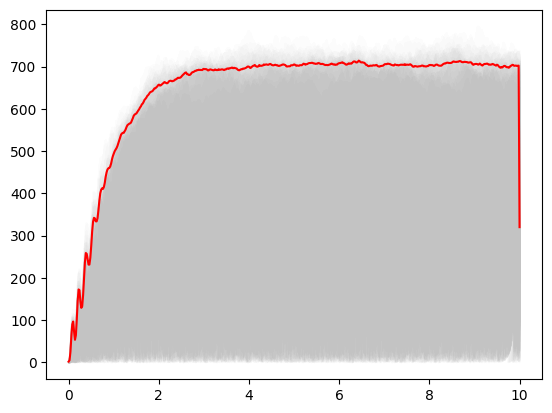

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x3068ca3c0>

In [45]:


function integrate_mcwf(
    st0::TavisCummingsState,
    model::MCWFModel,
    tspan;
    rng = Random.default_rng(),
    alg = Tsit5(),
    reltol = 1e-8,
    abstol = 1e-10,
)
    t0, tf = tspan
    t = t0
    st = copy(st0)

    saved_t = Float64[t]
    saved_st = TavisCummingsState[copy(st)]

    jump_t = Float64[]
    jump_idx = Int[]

    while t < tf
        Heff = effective_hamiltonian(model, st)
        threshold = rand(rng)
        jumped = Ref(false)

        function rhs!(du, u, p, tt)
            mul!(du, Heff, u)
            du .*= -1im
            return nothing
        end

        function condition(u, tt, integrator)
            return real(dot(u, u) - threshold)
        end

        function affect!(integrator)
            jumped[] = true
            terminate!(integrator)
            return nothing
        end

        cb = ContinuousCallback(condition, affect!; save_positions = (false, false))
        prob = ODEProblem(rhs!, copy(st.state), (t, tf), saveat = range(t, tf, 100))
        sol = solve(prob, alg; callback = cb, reltol = reltol, abstol = abstol, save_start = false)

        st.state = copy(sol.u[end])
        t = sol.t[end]

        push!(saved_t, t)
        push!(saved_st, copy(st))

        if !jumped[]
            break
        end

        rates = jump_rates(model, st)
        idx = sample_index(rates, rng)
        idx === nothing && break

        apply_jump!(model.jumps[idx], st, rng)

        push!(jump_t, t)
        push!(jump_idx, idx)

        push!(saved_t, t)
        push!(saved_st, copy(st))
    end

    return saved_t, saved_st, jump_t, jump_idx
end



function photon_number(st::TavisCummingsState)
    basis = states(st)
    ψ = st.state
    return real(sum(n * abs2(ψ[i]) for (i, (n, M)) in enumerate(basis)))
end

function photon_number_sq(st::TavisCummingsState)
    basis = states(st)
    ψ = st.state
    return real(sum(n^2 * abs2(ψ[i]) for (i, (n, M)) in enumerate(basis)))
end

function spin_projection(st::TavisCummingsState)
    basis = states(st)
    ψ = st.state
    return real(sum(M * abs2(ψ[i]) for (i, (n, M)) in enumerate(basis)))
end

function atomic_excitation_number(st::TavisCummingsState)
    basis = states(st)
    ψ = st.state
    return real(sum((st.S + M) * abs2(ψ[i]) for (i, (n, M)) in enumerate(basis)))
end

function total_excitation_number(st::TavisCummingsState)
    basis = states(st)
    ψ = st.state
    return real(sum((n + st.S + M) * abs2(ψ[i]) for (i, (n, M)) in enumerate(basis)))
end

function sample_trajectory(saved_t, saved_st, tgrid, obsfun)
    vals = zeros(length(tgrid))
    j = 1
    for i in eachindex(tgrid)
        t = tgrid[i]
        while j < length(saved_t) && saved_t[j+1] <= t
            j += 1
        end
        vals[i] = obsfun(saved_st[j])
    end
    return vals
end

N = 1000
decays = AtomicDecay(0.0, N)
pumps = AtomicPump(1.4, N)
dephs = AtomicDephasing(0.01, N)
Ls = vcat(CavityDecay(1.0), decays..., pumps..., dephs...)


model = MCWFModel(st -> TC_hamiltonian(st; g = 1.0), Ls)
st = TavisCummingsState(N ÷ 2, 2)
st.state[end] = 1.0

rng = Xoshiro(1234)

res = nothing
nruns = 20
tgrid = collect(range(0.0, 10.0, 500))

for runs in 1:nruns
    saved_t, saved_st, jump_t, jump_idx = integrate_mcwf(st, model, [tgrid[1], tgrid[end]]; rng = rng)
    plot(saved_t, photon_number.(saved_st), color = "k", alpha = 0.01)
    nr = sample_trajectory(saved_t, saved_st, tgrid, photon_number)
    if res !== nothing
        res += nr
    else
        res = nr
    end
end

plot(tgrid, res / nruns, color = "red")


# Spectrum calculation

In [44]:
function apply_a(st::TavisCummingsState)
    st.E == 0 && return nothing
    J = cavity_jump_operator(st)   # this is exactly the matrix for a, without sqrt(kappa)
    ψ = J * st.state
    st2 = TavisCummingsState(st.S, st.E - 1)
    st2.state .= ψ
    return st2
end

saved_t, saved_st, jump_t, jump_idx = integrate_mcwf(st, model, [tgrid[1], tgrid[end]]; rng = rng)
ρss = saved_st[end]
apply_a(ρss)

TavisCummingsState(13, 138, ComplexF64[6.882319746905333e-7 + 0.0im, 0.0 - 1.147345195022972e-6im, -1.0058109254806816e-6 + 0.0im, 0.0 - 4.990419155808244e-6im, 4.7965070622902275e-6 + 0.0im, 0.0 - 0.0001281216187688138im, -0.0007590900519734839 + 0.0im, 0.0 + 0.0017916414598637988im, 0.0004622918626371661 + 0.0im, 0.0 + 0.012874502637485496im  …  0.0 + 2.0343267058374157im, 0.6068656707490883 + 0.0im, 0.0 + 2.373335313357307im, 3.5690311534185475 + 0.0im, 0.0 - 1.2498928135434297im, 1.9160172892771612 + 0.0im, 0.0 - 2.545179463650381im, -0.9735763524122326 + 0.0im, 0.0 - 0.2826785125743212im, -0.10788770692979428 + 0.0im])